# Rubin/LSST — Stable Stars with Known Spectral Type: Rubin Visit Cross-Match

For each photometrically stable star with a **known spectral type** (from the
Simbad master catalogue built in notebook `01_findStarsinSimbad.ipynb`),
this notebook:

1. Loads the master Simbad catalogue and **filters to stars with a defined spectral type**.
2. Loads the Rubin visit table (`visitTable-..._WithTracts.parquet`).
3. **Cross-matches** each star against visits using a cone-search on the visit
   pointing (RA, Dec) — visit footprint approximated by Rubin FoV radius ≈ 1.75°.
4. Saves per-star visit lists (CSV + Parquet) in `data_SIMBAD_02/per_star/`.
5. Produces a **summary table** (visit counts per star × band, sorted by total
   visits descending).


- author : Sylvie Dagoret-Campagne
- affiliation : IJCLab/IN2P3/CNRS, Université Paris-Saclay
- creation : 2026-06-22
- last update : 2026-06-23
- input catalogue : `data_SIMBAD_01/master_stable_stars_V17-22_r1.5deg.csv`
- input visits : `../05_runbindata_visits/data_fromlsst/visitTable-2025041500138-2026053000760_N83426_WithTracts.parquet`


## 1. Imports & configuration

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from astropy.coordinates import SkyCoord
import astropy.units as u

warnings.filterwarnings("ignore")

print(f"numpy   version : {np.__version__}")
print(f"pandas  version : {pd.__version__}")

numpy   version : 1.26.4
pandas  version : 2.2.3


In [2]:
try:
    import ipympl  # noqa: F401

    %matplotlib widget
    print("ipympl found → interactive backend")
except ImportError:
    %matplotlib inline
    print("ipympl NOT found → inline")

ipympl found → interactive backend


In [5]:
# ── Paths ───────────────────────────────────────────────────────────────────────────
# Simbad master catalogue from notebook 01
PATH_SIMBAD_MASTER = "data_SIMBAD_01/master_stable_stars_V17-20_r1.5deg.csv"

# Rubin visit table (WithTracts parquet)
PATH_VISITS = (
    "../05_runbindata_visits/data_fromlsst/visitTable-2025041500138-2026053000760_N83426_WithTracts.parquet"
)

# ── Cross-match radius ─────────────────────────────────────────────────────────────
# Rubin field of view radius ~ 1.75 deg (diameter 3.5 deg).
# We match a star to a visit if the angular distance between the star and
# the visit pointing is smaller than MATCH_RADIUS_DEG.
MATCH_RADIUS_DEG = 1.75  # [adjustable]

# ── Bands to keep ────────────────────────────────────────────────────────────────
BANDS_TO_KEEP = ["u", "g", "r", "i", "z", "y"]  # exclude 'ph', 'unknown'

# ── Output directories ──────────────────────────────────────────────────────────────
NB_TAG = "SIMBAD_02"
DIR_DATA = f"data_{NB_TAG}"
DIR_FIGS = f"figs_{NB_TAG}"
DIR_STARS = os.path.join(DIR_DATA, "per_star")  # one file per star
os.makedirs(DIR_DATA, exist_ok=True)
os.makedirs(DIR_FIGS, exist_ok=True)
os.makedirs(DIR_STARS, exist_ok=True)
print(f"Data root : {os.path.abspath(DIR_DATA)}")
print(f"Per-star  : {os.path.abspath(DIR_STARS)}")
print(f"Figs      : {os.path.abspath(DIR_FIGS)}")

# ── Matplotlib style ───────────────────────────────────────────────────────────────
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 9,
    }
)


def savefig(name: str) -> None:
    for ext in ("pdf", "png"):
        plt.savefig(os.path.join(DIR_FIGS, f"{name}.{ext}"), bbox_inches="tight")
    print(f"  -> saved {name}.{chr(123)}pdf,png{chr(125)}")


print("Configuration done.")

Data root : /Users/dagoret/Desktop/RubinLSSTSkyAlerts/notebooks/10_askSimbad/data_SIMBAD_02
Per-star  : /Users/dagoret/Desktop/RubinLSSTSkyAlerts/notebooks/10_askSimbad/data_SIMBAD_02/per_star
Figs      : /Users/dagoret/Desktop/RubinLSSTSkyAlerts/notebooks/10_askSimbad/figs_SIMBAD_02
Configuration done.


## 2. Load the Simbad master catalogue

We load the master catalogue produced by `01_findStarsinSimbad.ipynb` and
**retain only stars whose spectral type is defined** (non-empty, not `?`, not `unknown`).


In [6]:
df_simbad = pd.read_csv(PATH_SIMBAD_MASTER)
print(f"Master catalogue shape  : {df_simbad.shape}")
print(f"Columns                 : {list(df_simbad.columns)}")
df_simbad.head(3)

Master catalogue shape  : (1347, 17)
Columns                 : ['simbad_id', 'ra_deg', 'dec_deg', 'V_mag', 'B_mag', 'R_mag', 'I_mag', 'simbad_otype', 'spectral_type', 'mk_class', 'mk_subtype', 'lum_class', 'parallax_mas', 'pmra_mas_yr', 'pmdec_mas_yr', 'stable', 'field']


,simbad_id,ra_deg,dec_deg,V_mag,B_mag,R_mag,I_mag,simbad_otype,spectral_type,mk_class,mk_subtype,lum_class,parallax_mas,pmra_mas_yr,pmdec_mas_yr,stable,field
0,2MASS J10010465+0227361,150.269422,2.460136,18.160999,18.471001,NaN,17.77,*,NaN,?,NaN,unknown,0.4111,-12.513,0.120,True,COSMOS
1,COSMOS 818920,150.394436,1.889753,18.284000,18.403999,NaN,18.17,*,NaN,?,NaN,unknown,0.3684,-1.894,-3.533,True,COSMOS
2,2MASS J09574311+0217297,149.429657,2.291566,18.294001,19.148001,NaN,NaN,*,NaN,?,NaN,unknown,0.9310,-6.644,6.332,True,COSMOS


In [7]:
pd.set_option('display.max_rows', 50)

In [8]:
def has_known_spectral_type(sp) -> bool:
    """Return True when sp is a meaningful spectral-type string."""
    if pd.isna(sp):
        return False
    s = str(sp).strip()
    return s not in ("", "?", "unknown", "--", "nan", "None")


mask_sp = df_simbad["spectral_type"].apply(has_known_spectral_type)
df_stars = df_simbad[mask_sp].copy().reset_index(drop=True)

print(f"Stars with known spectral type : {len(df_stars)} / {len(df_simbad)}")
print("Spectral-type values (top-15)  :")
print(df_stars["spectral_type"].value_counts().head(15).to_string())
df_stars[["simbad_id", "ra_deg", "dec_deg", "V_mag", "spectral_type", "field"]]

Stars with known spectral type : 18 / 1347
Spectral-type values (top-15)  :
spectral_type
M5       3
F5       2
K7       2
F8III    1
M4V      1
M1e      1
M3       1
A0       1
F8       1
M3.8     1
M1       1
M0.0     1
M2.0     1
sdA      1


,simbad_id,ra_deg,dec_deg,V_mag,spectral_type,field
0,COSMOS 2804135,149.618730,2.752116,18.471001,F5,COSMOS
1,2MASS J09595063+0223163,149.960974,2.387758,18.493000,K7,COSMOS
2,DENIS J095927.3+015559,149.863906,1.933192,18.757000,F8III,COSMOS
3,2MASS J10000275+0231274,150.011475,2.524314,18.834000,M4V,COSMOS
4,ACS-GC 20099329,149.754089,2.141825,18.875000,M1e,COSMOS
5,SDSS J100109.02+021351.0,150.287607,2.230831,18.927999,K7,COSMOS
6,2MASS J10003351+0205430,150.139659,2.095297,18.927999,M3,COSMOS
7,SDSS J100158.92+021246.1,150.495534,2.212809,18.955999,A0,COSMOS
8,2MASS J10002097+0144317,150.087410,1.742118,19.121000,M5,COSMOS
9,SDSS J095808.75+020000.9,149.536490,2.000254,19.211000,F8,COSMOS


In [9]:
print("Breakdown by DDF field:")
print(df_stars["field"].value_counts().to_string())

Breakdown by DDF field:
field
COSMOS     15
ECDFS       2
XMM-LSS     1


In [10]:
# ── Extract simple MK temperature class from the first character of spectral_type
def mk_class_from_sptype(sp: str) -> str:
    s = str(sp).strip().upper()
    for cls in ("O", "B", "A", "F", "G", "K", "M", "L", "T", "Y", "W", "C", "S"):
        if s.startswith(cls):
            return cls
    return "?"


df_stars["mk_class_simple"] = df_stars["spectral_type"].apply(mk_class_from_sptype)
print("MK class distribution:")
print(df_stars["mk_class_simple"].value_counts().to_string())

MK class distribution:
mk_class_simple
M    10
F     4
K     2
A     1
S     1


## 3. Load the Rubin visit table

We load the full visit table and **pre-filter to science-quality bands**
(u, g, r, i, z, y) to discard engineering (`ph`, `unknown`) entries.
We also compute the **airmass** from the zenith angle: X = 1 / cos(zenith_angle).


In [11]:
df_visits_raw = pd.read_parquet(PATH_VISITS)
print(f"Visit table raw shape : {df_visits_raw.shape}")
print(f"Bands present         : {sorted(df_visits_raw['band'].unique())}")
df_visits_raw[["id", "band", "ra", "dec", "zenith_angle", "mjd", "tract", "patch", "target"]].head(3)

Visit table raw shape : (83426, 26)
Bands present         : ['g', 'i', 'ph', 'r', 'u', 'unknown', 'y', 'z']


,id,band,ra,dec,zenith_angle,mjd,tract,patch,target
1,2025041500138,i,188.003523,-4.674351,26.164637,60781.170034,8626,81,HD 106625
2,2025041500139,i,177.607603,-14.112866,22.940351,60781.172641,7183,51,HD 106625
3,2025041500140,i,183.952462,-17.541894,16.725706,60781.174326,6719,24,HD 106625


In [12]:
# ── Keep only science bands
df_visits = df_visits_raw[df_visits_raw["band"].isin(BANDS_TO_KEEP)].copy()
df_visits.reset_index(drop=True, inplace=True)

# ── Airmass: plane-parallel approximation X = sec(z) = 1/cos(z_rad)
df_visits["airmass"] = 1.0 / np.cos(np.radians(df_visits["zenith_angle"]))

# ── Rename id → visitId
df_visits.rename(columns={"id": "visitId"}, inplace=True)

# ── Select columns of interest
VISIT_COLS = [
    "visitId",
    "band",
    "ra",
    "dec",
    "mjd",
    "airmass",
    "zenith_angle",
    "tract",
    "patch",
    "patch_str",
    "day_obs",
    "seq_num",
    "time_start",
    "target",
]
df_visits = df_visits[VISIT_COLS]

print(f"Visit table filtered shape : {df_visits.shape}")
print(f"Bands kept                 : {sorted(df_visits['band'].unique())}")
print(f"Airmass range              : [{df_visits['airmass'].min():.3f}, {df_visits['airmass'].max():.3f}]")
df_visits.head(3)

Visit table filtered shape : (83418, 14)
Bands kept                 : ['g', 'i', 'r', 'u', 'y', 'z']
Airmass range              : [1.004, 3.373]


,visitId,band,ra,dec,mjd,airmass,zenith_angle,tract,patch,patch_str,day_obs,seq_num,time_start,target
0,2025041500138,i,188.003523,-4.674351,60781.170034,1.114168,26.164637,8626,81,"1,8",20250415,138,2025-04-16T04:04:50.965,HD 106625
1,2025041500139,i,177.607603,-14.112866,60781.172641,1.085881,22.940351,7183,51,"1,5",20250415,139,2025-04-16T04:08:36.184,HD 106625
2,2025041500140,i,183.952462,-17.541894,60781.174326,1.044175,16.725706,6719,24,"4,2",20250415,140,2025-04-16T04:11:01.794,HD 106625


## 4. Build SkyCoord arrays for fast angular cross-match

We use `astropy.coordinates.SkyCoord.separation()` to compute the angular distance
between each star and all visit pointings. The visit SkyCoord array is built **once**
before the star loop for efficiency.


In [13]:
# SkyCoord for ALL visits (built once)
visit_coords = SkyCoord(
    ra=df_visits["ra"].values * u.deg,
    dec=df_visits["dec"].values * u.deg,
    frame="icrs",
)
print(f"Visit SkyCoord array : {len(visit_coords)} entries")

# SkyCoord for ALL stars (used for sky-distribution plot later)
star_coords = SkyCoord(
    ra=df_stars["ra_deg"].values * u.deg,
    dec=df_stars["dec_deg"].values * u.deg,
    frame="icrs",
)
print(f"Star SkyCoord array  : {len(star_coords)} entries")

Visit SkyCoord array : 83418 entries
Star SkyCoord array  : 18 entries


## 5. Per-star visit cross-match and saving

For each star we:
- Select visits within `MATCH_RADIUS_DEG` of the star's sky position.
- Annotate the sub-table with star metadata (`simbad_id`, `spectral_type`, `V_mag`, `field`).
- Save CSV + Parquet in `data_SIMBAD_02/per_star/<star_id>.{csv,parquet}`.
- Accumulate per-band counts for the summary table.


In [14]:
match_radius = MATCH_RADIUS_DEG * u.deg
summary_rows = []

for idx, star in df_stars.iterrows():
    star_coord = SkyCoord(ra=star["ra_deg"] * u.deg, dec=star["dec_deg"] * u.deg, frame="icrs")

    sep = star_coord.separation(visit_coords)
    in_fov = sep < match_radius
    df_match = df_visits[in_fov].copy()

    row = {
        "simbad_id": star["simbad_id"],
        "spectral_type": star["spectral_type"],
        "mk_class_simple": star.get("mk_class_simple", "?"),
        "V_mag": star["V_mag"],
        "ra_deg": star["ra_deg"],
        "dec_deg": star["dec_deg"],
        "field": star["field"],
        "n_visits_total": len(df_match),
    }
    for b in BANDS_TO_KEEP:
        row[f"n_{b}"] = 0

    if not df_match.empty:
        df_match["simbad_id"] = star["simbad_id"]
        df_match["spectral_type"] = star["spectral_type"]
        df_match["V_mag"] = star["V_mag"]
        df_match["field"] = star["field"]

        star_id_clean = star["simbad_id"].replace(" ", "_").replace("/", "-").replace(":", "-")

        df_match.to_csv(os.path.join(DIR_STARS, f"{star_id_clean}.csv"), index=False)
        df_match.to_parquet(os.path.join(DIR_STARS, f"{star_id_clean}.parquet"), index=False)

        band_counts = df_match["band"].value_counts()
        for b in BANDS_TO_KEEP:
            row[f"n_{b}"] = int(band_counts.get(b, 0))

    summary_rows.append(row)

    if (idx + 1) % 20 == 0 or (idx + 1) == len(df_stars):
        print(f"  [{idx + 1:4d}/{len(df_stars)}] {star['simbad_id']:40s}  → {len(df_match):5d} visits")

print(f"\nDone. Per-star files saved to: {os.path.abspath(DIR_STARS)}")

  [  18/18] SDSS J021726.52-050827.3                  →   222 visits

Done. Per-star files saved to: /Users/dagoret/Desktop/RubinLSSTSkyAlerts/notebooks/10_askSimbad/data_SIMBAD_02/per_star


## 6. Summary table — visit counts per star × band

One row per star, sorted by `n_visits_total` descending.
Saved as CSV and Parquet in `data_SIMBAD_02/`.


In [15]:
df_summary = pd.DataFrame(summary_rows)
df_summary.sort_values("n_visits_total", ascending=False, inplace=True)
df_summary.reset_index(drop=True, inplace=True)

col_order = [
    "simbad_id",
    "spectral_type",
    "mk_class_simple",
    "V_mag",
    "ra_deg",
    "dec_deg",
    "field",
    "n_visits_total",
] + [f"n_{b}" for b in BANDS_TO_KEEP]
df_summary = df_summary[col_order]

print(f"Summary table shape : {df_summary.shape}")
df_summary.head(15)

Summary table shape : (18, 14)


,simbad_id,spectral_type,mk_class_simple,V_mag,ra_deg,dec_deg,field,n_visits_total,n_u,n_g,n_r,n_i,n_z,n_y
0,SDSS J095808.75+020000.9,F8,F,19.211000,149.536490,2.000254,COSMOS,2274,191,397,468,691,409,118
1,2MASS J10004035+0236565,M5,M,19.354000,150.168171,2.615689,COSMOS,2274,191,397,470,690,408,118
2,ACS-GC 20099329,M1e,M,18.875000,149.754089,2.141825,COSMOS,2274,191,397,468,691,408,119
3,2MASS J10003351+0205430,M3,M,18.927999,150.139659,2.095297,COSMOS,2274,191,397,469,691,408,118
4,2MASS J10003105+0241554,M3.8,M,19.493999,150.129406,2.698776,COSMOS,2274,191,397,470,690,408,118
5,COSMOS 2685690,F5,F,19.301001,150.069783,2.744172,COSMOS,2274,191,397,470,690,408,118
6,DENIS J095927.3+015559,F8III,F,18.757000,149.863906,1.933192,COSMOS,2273,191,397,468,690,408,119
7,SDSS J100022.20+021019.8,M1,M,19.802000,150.092527,2.172172,COSMOS,2273,191,397,469,690,408,118
8,COSMOS 1235283,M5,M,19.634001,150.206324,2.120730,COSMOS,2273,191,397,469,690,408,118
9,2MASS J10002097+0144317,M5,M,19.121000,150.087410,1.742118,COSMOS,2273,191,397,468,690,409,118


In [16]:
out_csv = os.path.join(DIR_DATA, "summary_visit_counts_per_star.csv")
out_parquet = os.path.join(DIR_DATA, "summary_visit_counts_per_star.parquet")
df_summary.to_csv(out_csv, index=False)
df_summary.to_parquet(out_parquet, index=False)
print(f"Saved: {out_csv}")
print(f"Saved: {out_parquet}")

Saved: data_SIMBAD_02/summary_visit_counts_per_star.csv
Saved: data_SIMBAD_02/summary_visit_counts_per_star.parquet


In [17]:
print("=== Visit-count statistics (total visits per star) ===")
print(df_summary["n_visits_total"].describe().to_string())
print()
print("=== Stars with >= 100 visits ===")
print(
    df_summary[df_summary["n_visits_total"] >= 100][
        ["simbad_id", "spectral_type", "field", "n_visits_total"]
    ].to_string()
)

=== Visit-count statistics (total visits per star) ===
count      18.000000
mean     1963.055556
std       715.411397
min       222.000000
25%      2271.250000
50%      2273.000000
75%      2274.000000
max      2274.000000

=== Stars with >= 100 visits ===
                   simbad_id spectral_type    field  n_visits_total
0   SDSS J095808.75+020000.9            F8   COSMOS            2274
1    2MASS J10004035+0236565            M5   COSMOS            2274
2            ACS-GC 20099329           M1e   COSMOS            2274
3    2MASS J10003351+0205430            M3   COSMOS            2274
4    2MASS J10003105+0241554          M3.8   COSMOS            2274
5             COSMOS 2685690            F5   COSMOS            2274
6     DENIS J095927.3+015559         F8III   COSMOS            2273
7   SDSS J100022.20+021019.8            M1   COSMOS            2273
8             COSMOS 1235283            M5   COSMOS            2273
9    2MASS J10002097+0144317            M5   COSMOS            

## 7. Visualisations

### 7.1  MK spectral-class composition per DDF (stacked barplot)

One bar per DDF field; each bar is colour-stacked by MK temperature class (O/B/A/F/G/K/M/…).
This representation reveals minority spectral types that are invisible in overlapping histograms.


  -> saved barplot_mk_class_per_ddf.{pdf,png}


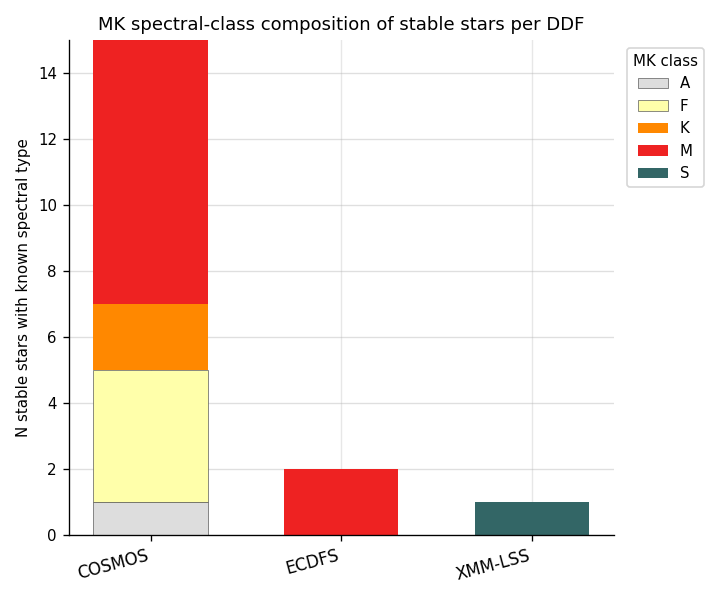

In [18]:
# ── Palette: one colour per MK class, in temperature order O→M + unknowns ────────
MK_ORDER = ["O", "B", "A", "F", "G", "K", "M", "L", "T", "W", "C", "S", "?"]
MK_COLORS = {
    "O": "#6699FF",  # blue-violet
    "B": "#99CCFF",  # light blue
    "A": "#DDDDDD",  # light grey  (white stars → use grey for visibility)
    "F": "#FFFFAA",  # pale yellow
    "G": "#FFDD00",  # yellow  (Sun-like)
    "K": "#FF8800",  # orange
    "M": "#EE2222",  # red
    "L": "#993300",  # brown
    "T": "#663300",  # dark brown
    "W": "#CC33FF",  # violet (Wolf-Rayet)
    "C": "#009966",  # green (carbon)
    "S": "#336666",  # teal
    "?": "#AAAAAA",  # grey (unclassified)
}

# ── Cross-tabulation: rows = DDF field, columns = MK class ──────────────────────
ct = df_summary.groupby(["field", "mk_class_simple"]).size().unstack(fill_value=0)
mk_present = [c for c in MK_ORDER if c in ct.columns]
ct = ct[mk_present]

fields = ct.index.tolist()
x = np.arange(len(fields))
bar_w = 0.6

fig, ax = plt.subplots(figsize=(max(6, len(fields) * 1.5), 5))
bottom = np.zeros(len(fields))
for cls in mk_present:
    vals = ct[cls].values.astype(float)
    color = MK_COLORS.get(cls, "#CCCCCC")
    ec = "#555555" if color in ("#DDDDDD", "#FFFFAA", "#FFDD00") else "none"
    ax.bar(x, vals, bar_w, bottom=bottom, label=cls, color=color, edgecolor=ec, linewidth=0.4)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(fields, fontsize=10, rotation=15, ha="right")
ax.set_ylabel("N stable stars with known spectral type")
ax.set_title("MK spectral-class composition of stable stars per DDF")
ax.legend(title="MK class", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, framealpha=0.8)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
savefig("barplot_mk_class_per_ddf")
plt.show()

### 7.2  N visits per star per DDF — stacked by band (subplots)

One subplot per DDF field.
X axis = Simbad star name (sorted by total visits descending).
Y axis = N visits, colour-stacked in band order u → g → r → i → z → y.


  -> saved barplot_visits_per_star_per_ddf.{pdf,png}


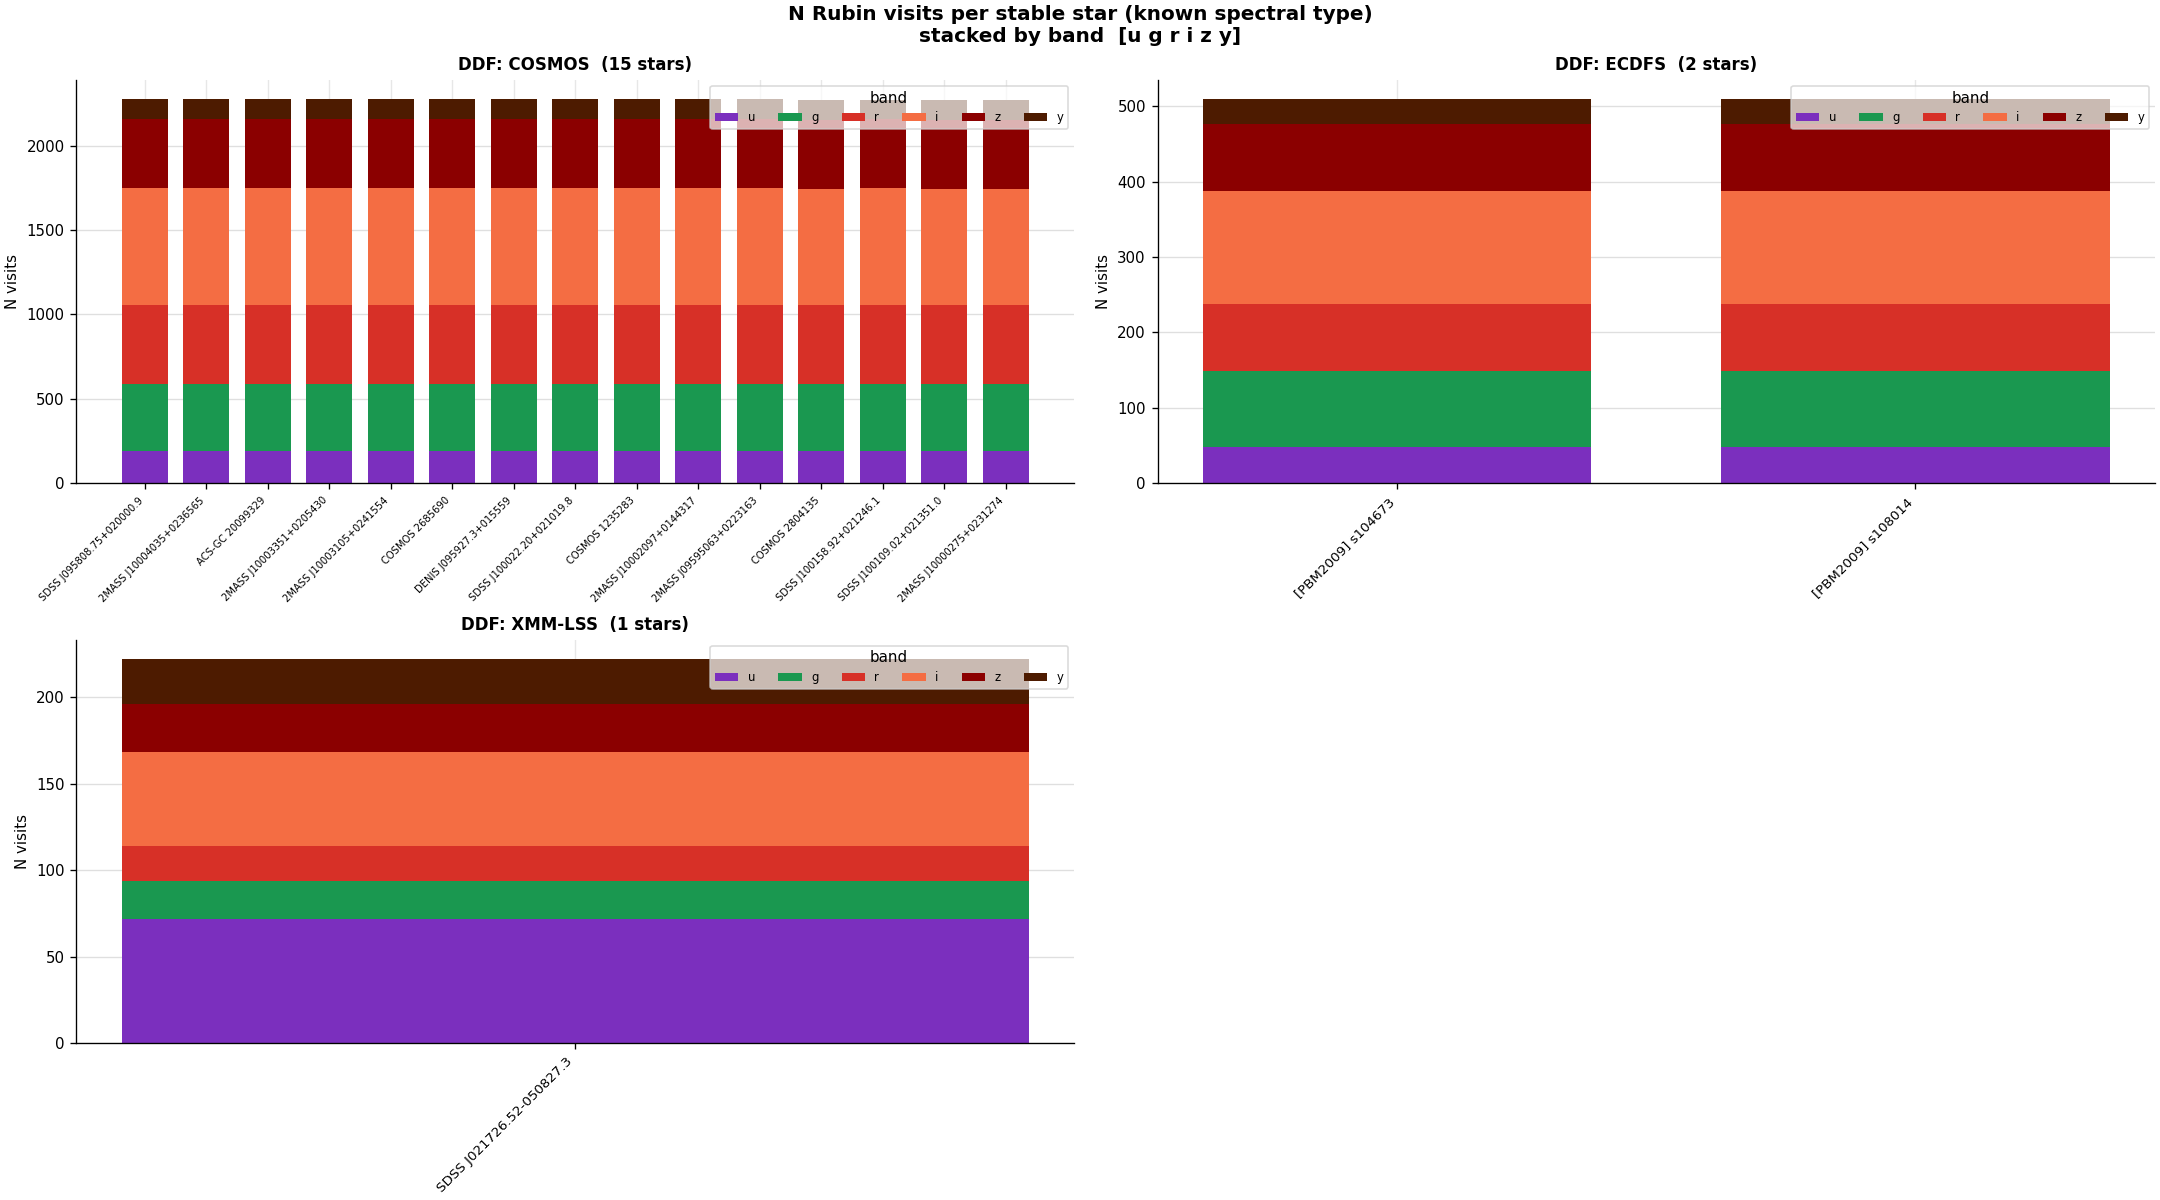

In [19]:
# ── Band colour palette (wavelength order u=violet … y=near-IR) ─────────────────
BAND_COLORS = {
    "u": "#7B2FBE",  # violet
    "g": "#1A9850",  # green
    "r": "#D73027",  # red
    "i": "#F46D43",  # orange
    "z": "#8B0000",  # dark red
    "y": "#4D1B00",  # near-IR brown
}

fields_ordered = sorted(df_summary["field"].unique())
n_fields = len(fields_ordered)

# ── Layout: 2 columns ────────────────────────────────────────────────────────────
ncols = min(2, n_fields)
nrows = int(np.ceil(n_fields / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 9, nrows * 5), constrained_layout=True)
axes_flat = np.array(axes).flatten()

for ax_idx, field in enumerate(fields_ordered):
    ax = axes_flat[ax_idx]
    sub = (
        df_summary[df_summary["field"] == field]
        .sort_values("n_visits_total", ascending=False)
        .reset_index(drop=True)
    )

    if sub.empty:
        ax.set_visible(False)
        continue

    x_pos = np.arange(len(sub))
    bar_w = 0.75
    bottom = np.zeros(len(sub))

    for band in BANDS_TO_KEEP:
        vals = sub[f"n_{band}"].values.astype(float)
        ax.bar(x_pos, vals, bar_w, bottom=bottom, label=band, color=BAND_COLORS[band])
        bottom += vals

    # X-tick labels: font size adapts to the number of stars
    xlabels = sub["simbad_id"].tolist()
    tick_fs = max(4, min(8, 90 // max(len(xlabels), 1)))
    ax.set_xticks(x_pos)
    ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=tick_fs)

    ax.set_ylabel("N visits")
    ax.set_title(f"DDF: {field}  ({len(sub)} stars)", fontsize=10, fontweight="bold")
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(title="band", ncol=6, fontsize=7, loc="upper right", framealpha=0.7)

# Hide unused subplots
for ax_idx in range(n_fields, len(axes_flat)):
    axes_flat[ax_idx].set_visible(False)

fig.suptitle(
    "N Rubin visits per stable star (known spectral type)\nstacked by band  [u g r i z y]",
    fontsize=12,
    fontweight="bold",
)
savefig("barplot_visits_per_star_per_ddf")
plt.show()

### 7.3  Total visits distribution by MK spectral class

  -> saved hist_visits_by_mk_class.{pdf,png}


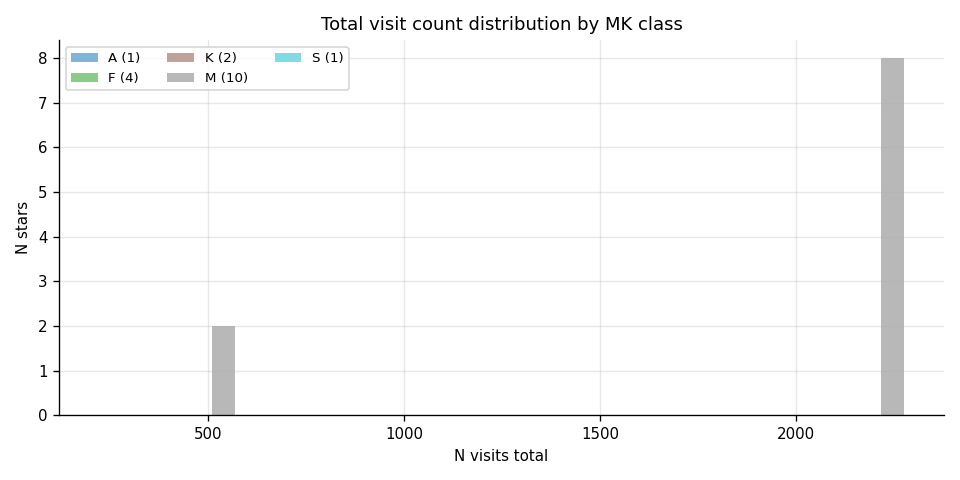

In [20]:
mk_classes = sorted(df_summary["mk_class_simple"].unique())
cmap_mk = cm.get_cmap("tab10", len(mk_classes))

fig, ax = plt.subplots(figsize=(8, 4))
for i, cls in enumerate(mk_classes):
    sub = df_summary[df_summary["mk_class_simple"] == cls]["n_visits_total"]
    if sub.empty:
        continue
    ax.hist(sub, bins=30, alpha=0.55, label=f"{cls} ({len(sub)})", color=cmap_mk(i))
ax.set_xlabel("N visits total")
ax.set_ylabel("N stars")
ax.set_title("Total visit count distribution by MK class")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
savefig("hist_visits_by_mk_class")
plt.show()

### 7.4  Sky distribution coloured by total visit count

  -> saved sky_distribution_visit_count.{pdf,png}


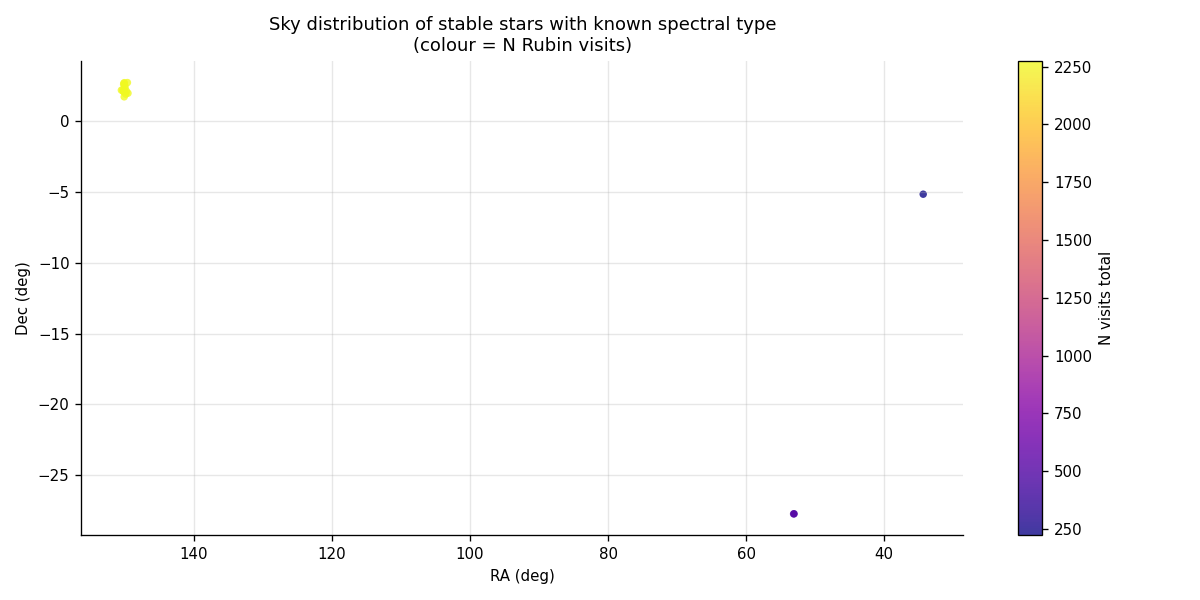

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    df_summary["ra_deg"],
    df_summary["dec_deg"],
    c=df_summary["n_visits_total"],
    cmap="plasma",
    s=20,
    alpha=0.8,
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label="N visits total")
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Sky distribution of stable stars with known spectral type\n(colour = N Rubin visits)")
ax.invert_xaxis()
plt.tight_layout()
savefig("sky_distribution_visit_count")
plt.show()

### 7.5  Per-band visit counts vs. V magnitude

  -> saved visits_vs_vmag_per_band.{pdf,png}


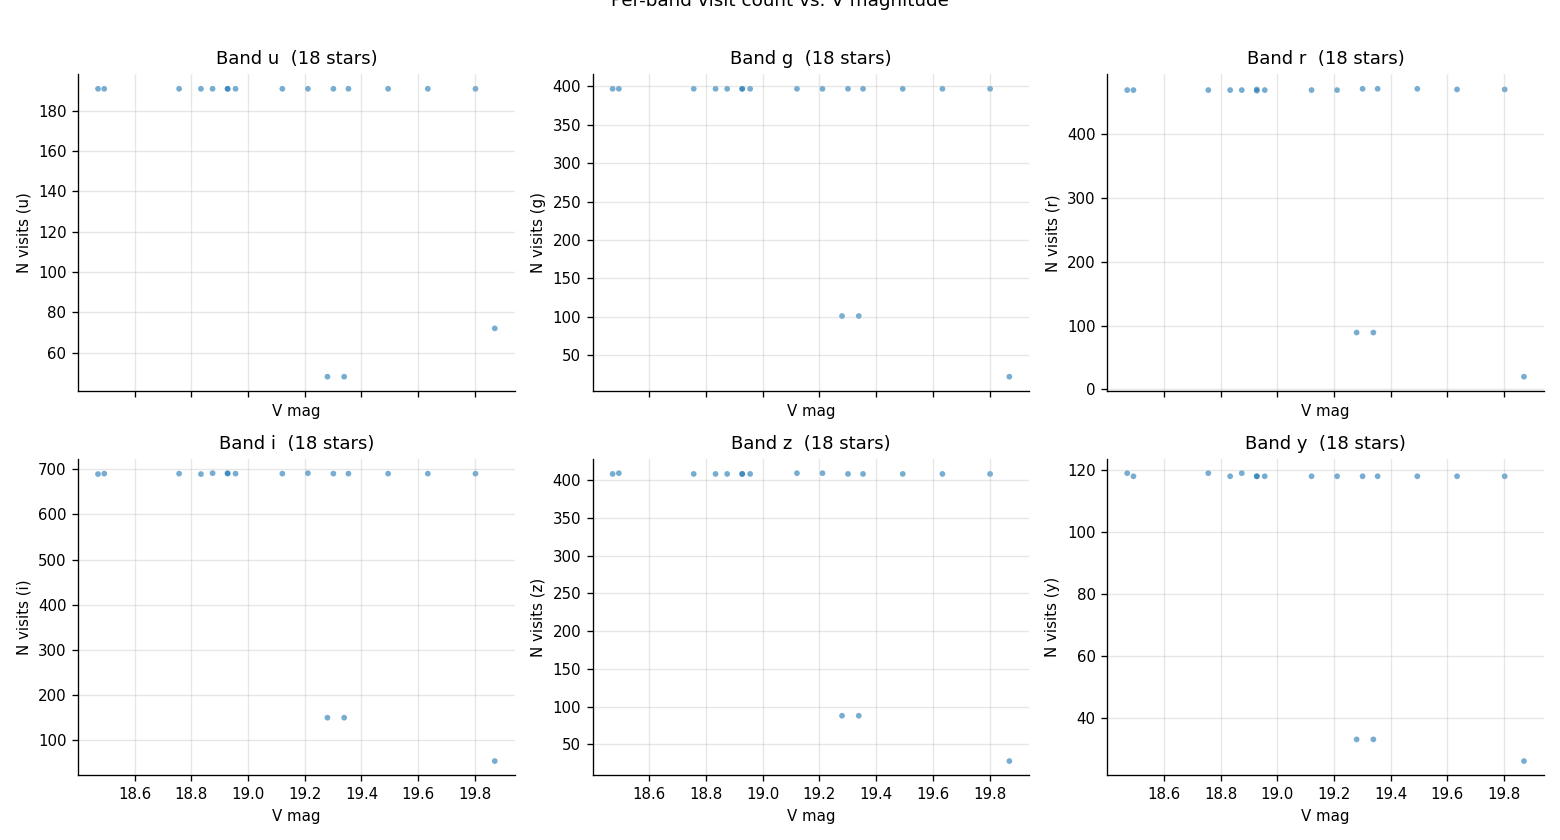

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
axes = axes.flatten()

for i, band in enumerate(BANDS_TO_KEEP):
    ax = axes[i]
    col = f"n_{band}"
    sub = df_summary[df_summary[col] > 0]
    ax.scatter(sub["V_mag"], sub[col], s=12, alpha=0.6, edgecolors="none")
    ax.set_title(f"Band {band}  ({len(sub)} stars)")
    ax.set_xlabel("V mag")
    ax.set_ylabel(f"N visits ({band})")

plt.suptitle("Per-band visit count vs. V magnitude", y=1.01, fontsize=11)
plt.tight_layout()
savefig("visits_vs_vmag_per_band")
plt.show()

## 8. Example: visit list for the best-observed star

Display the full visit list for the star with the highest total visit count,
and plot its MJD timeline coloured by band.


In [23]:
best_star = df_summary.iloc[0]
print("Best-observed star:")
print(f"  simbad_id     : {best_star['simbad_id']}")
print(f"  spectral_type : {best_star['spectral_type']}")
print(f"  V_mag         : {best_star['V_mag']:.2f}")
print(f"  field         : {best_star['field']}")
print(f"  n_visits_total: {best_star['n_visits_total']}")
for b in BANDS_TO_KEEP:
    print(f"    n_{b}: {int(best_star[f'n_{b}'])}")

Best-observed star:
  simbad_id     : SDSS J095808.75+020000.9
  spectral_type : F8
  V_mag         : 19.21
  field         : COSMOS
  n_visits_total: 2274
    n_u: 191
    n_g: 397
    n_r: 468
    n_i: 691
    n_z: 409
    n_y: 118


In [24]:
star_id_clean = best_star["simbad_id"].replace(" ", "_").replace("/", "-").replace(":", "-")
path_best = os.path.join(DIR_STARS, f"{star_id_clean}.parquet")

df_best = pd.read_parquet(path_best)
print(f"Shape of visit list: {df_best.shape}")
df_best[["visitId", "band", "mjd", "airmass", "ra", "dec", "tract", "patch_str", "time_start"]].head(10)

Shape of visit list: (2274, 18)


,visitId,band,mjd,airmass,ra,dec,tract,patch_str,time_start
0,2025051500122,i,60811.041905,1.339934,150.196620,2.249044,9813,"5,5",2025-05-16T01:00:20.631
1,2025051500123,i,60811.042377,1.340381,150.239941,2.179838,9813,"5,4",2025-05-16T01:01:01.399
2,2025051500124,i,60811.042852,1.342413,150.259178,2.186500,9813,"4,4",2025-05-16T01:01:42.409
3,2025051500125,i,60811.043332,1.342749,150.201347,2.029064,9813,"5,3",2025-05-16T01:02:23.892
4,2025051500126,i,60811.043806,1.349431,150.008579,2.146575,9813,"6,4",2025-05-16T01:03:04.841
5,2025051500127,i,60811.044280,1.348276,150.257476,2.138930,9813,"4,4",2025-05-16T01:03:45.761
6,2025051500128,i,60811.044759,1.355016,150.059933,2.248270,9813,"6,5",2025-05-16T01:04:27.156
7,2025051500129,i,60811.045235,1.359514,149.986389,2.318795,9813,"6,5",2025-05-16T01:05:08.286
8,2025051500130,i,60811.045712,1.353788,150.205133,2.019105,9813,"5,3",2025-05-16T01:05:49.480
9,2025051500131,i,60811.046184,1.359693,150.090348,2.139823,9813,"5,4",2025-05-16T01:06:30.292


  -> saved timeline_SDSS_J095808.75+020000.9.{pdf,png}


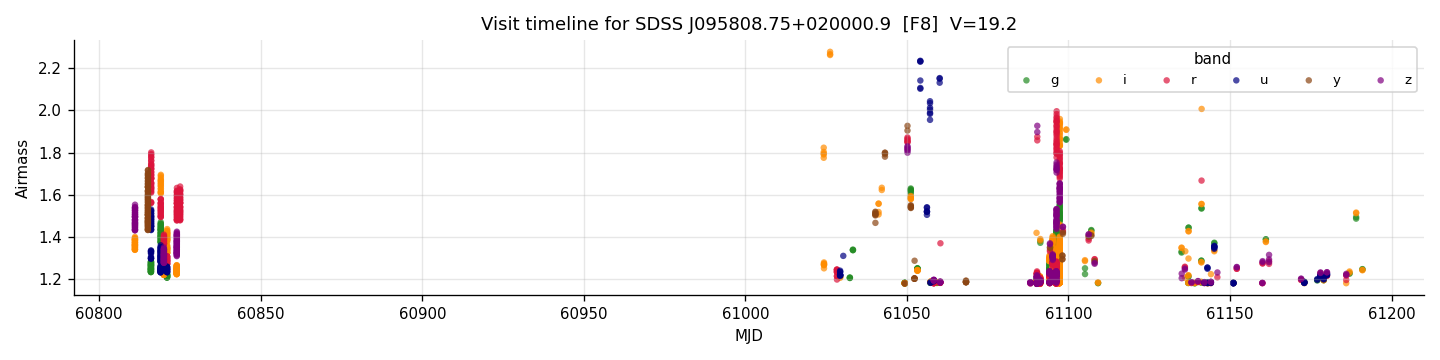

In [25]:
band_colors = {
    "u": "navy",
    "g": "forestgreen",
    "r": "crimson",
    "i": "darkorange",
    "z": "purple",
    "y": "saddlebrown",
}

fig, ax = plt.subplots(figsize=(12, 3))
for band, grp in df_best.groupby("band"):
    ax.scatter(
        grp["mjd"],
        grp["airmass"],
        label=band,
        color=band_colors.get(band, "grey"),
        s=15,
        alpha=0.7,
        edgecolors="none",
    )
ax.set_xlabel("MJD")
ax.set_ylabel("Airmass")
ax.set_title(
    f"Visit timeline for {best_star['simbad_id']}  [{best_star['spectral_type']}]  V={best_star['V_mag']:.1f}"
)
ax.legend(title="band", ncol=6, fontsize=8)
plt.tight_layout()
savefig(f"timeline_{star_id_clean}")
plt.show()

## 9. Printed summary table (top 30 stars)

Final pretty-printed summary sorted by total visit count.


In [26]:
cols_display = ["simbad_id", "spectral_type", "mk_class_simple", "V_mag", "field", "n_visits_total"] + [
    f"n_{b}" for b in BANDS_TO_KEEP
]

pd.set_option("display.max_colwidth", 35)
pd.set_option("display.max_rows", 30)
df_summary[cols_display].head(30)

,simbad_id,spectral_type,mk_class_simple,V_mag,field,n_visits_total,n_u,n_g,n_r,n_i,n_z,n_y
0,SDSS J095808.75+020000.9,F8,F,19.211000,COSMOS,2274,191,397,468,691,409,118
1,2MASS J10004035+0236565,M5,M,19.354000,COSMOS,2274,191,397,470,690,408,118
2,ACS-GC 20099329,M1e,M,18.875000,COSMOS,2274,191,397,468,691,408,119
3,2MASS J10003351+0205430,M3,M,18.927999,COSMOS,2274,191,397,469,691,408,118
4,2MASS J10003105+0241554,M3.8,M,19.493999,COSMOS,2274,191,397,470,690,408,118
5,COSMOS 2685690,F5,F,19.301001,COSMOS,2274,191,397,470,690,408,118
6,DENIS J095927.3+015559,F8III,F,18.757000,COSMOS,2273,191,397,468,690,408,119
7,SDSS J100022.20+021019.8,M1,M,19.802000,COSMOS,2273,191,397,469,690,408,118
8,COSMOS 1235283,M5,M,19.634001,COSMOS,2273,191,397,469,690,408,118
9,2MASS J10002097+0144317,M5,M,19.121000,COSMOS,2273,191,397,468,690,409,118


In [27]:
print("=" * 62)
print("Summary")
print("=" * 62)
print(f"  Total stable stars with known spectral type : {len(df_stars)}")
print(f"  Stars with >= 1 Rubin visit                : {(df_summary['n_visits_total'] > 0).sum()}")
print(f"  Stars with   0 Rubin visits                : {(df_summary['n_visits_total'] == 0).sum()}")
print(f"  Per-star files saved in                    : {os.path.abspath(DIR_STARS)}")
print(f"  Summary table saved in                     : {os.path.abspath(DIR_DATA)}")

Summary
  Total stable stars with known spectral type : 18
  Stars with >= 1 Rubin visit                : 18
  Stars with   0 Rubin visits                : 0
  Per-star files saved in                    : /Users/dagoret/Desktop/RubinLSSTSkyAlerts/notebooks/10_askSimbad/data_SIMBAD_02/per_star
  Summary table saved in                     : /Users/dagoret/Desktop/RubinLSSTSkyAlerts/notebooks/10_askSimbad/data_SIMBAD_02
